In [ ]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [1]:
!pip install numpy pandas opencv-python matplotlib tensorflow pillow scikit-learn
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
np.random.seed(42)
from matplotlib import style
style.use('fivethirtyeight')

In [ ]:
data_dir = "/content/drive/MyDrive/traffic"
train_path = '/content/drive/MyDrive/traffic/Train'
test_path = '/content/drive/MyDrive/traffic/Test'
# Resizing the images to 30x30x3
IMG_HEIGHT = 30
IMG_WIDTH=30
channels = 3

In [ ]:
NUM_CATEGORIES = len(os.listdir (train_path))
NUM_CATEGORIES

43

In [ ]:
# Label Overview
classes = {0: 'Speed limit (20km/h)',
1: 'Speed limit (30km/h)',
2: 'Speed limit (50km/h)',
3: 'Speed limit (60km/h)',
4: 'Speed limit (70km/h)',
5: 'Speed limit (80km/h)',
6: 'End of speed limit (80km/h)',
7: 'Speed limit (100km/h)',
8: 'Speed limit (120km/h)',
9: 'No passing',
10: 'No passing veh over 3.5 tons',
11: 'Right-of-way at intersection',
12: 'Priority road',
13: 'Yield',
14: 'Stop',
15: 'No vehicles',
16: 'Veh > 3.5 tons prohibited',
17: 'No entry',
18: 'General caution',
19: 'Dangerous curve left',
20: 'Dangerous curve right',
21: 'Double curve',
22: 'Bumpy road',
23: 'Slippery road',
24: 'Road narrows on the right',
25: 'Road work',
26: 'Traffic signals',
27: 'Pedestrians',
28: 'Children crossing',
29: 'Bicycles crossing',
30: 'Beware of ice/snow',
31: 'Wild animals crossing',
32: 'End speed + passing limits',
33: 'Turn right ahead',
34: 'Turn left ahead',
35: 'Ahead only',
36: 'Go straight or right',
37: 'Go straight or left',
38: 'Keep right',
39: 'Keep left',
40: 'Roundabout mandatory',
41: 'End of no passing',
42: 'End no passing veh > 3.5 tons' }

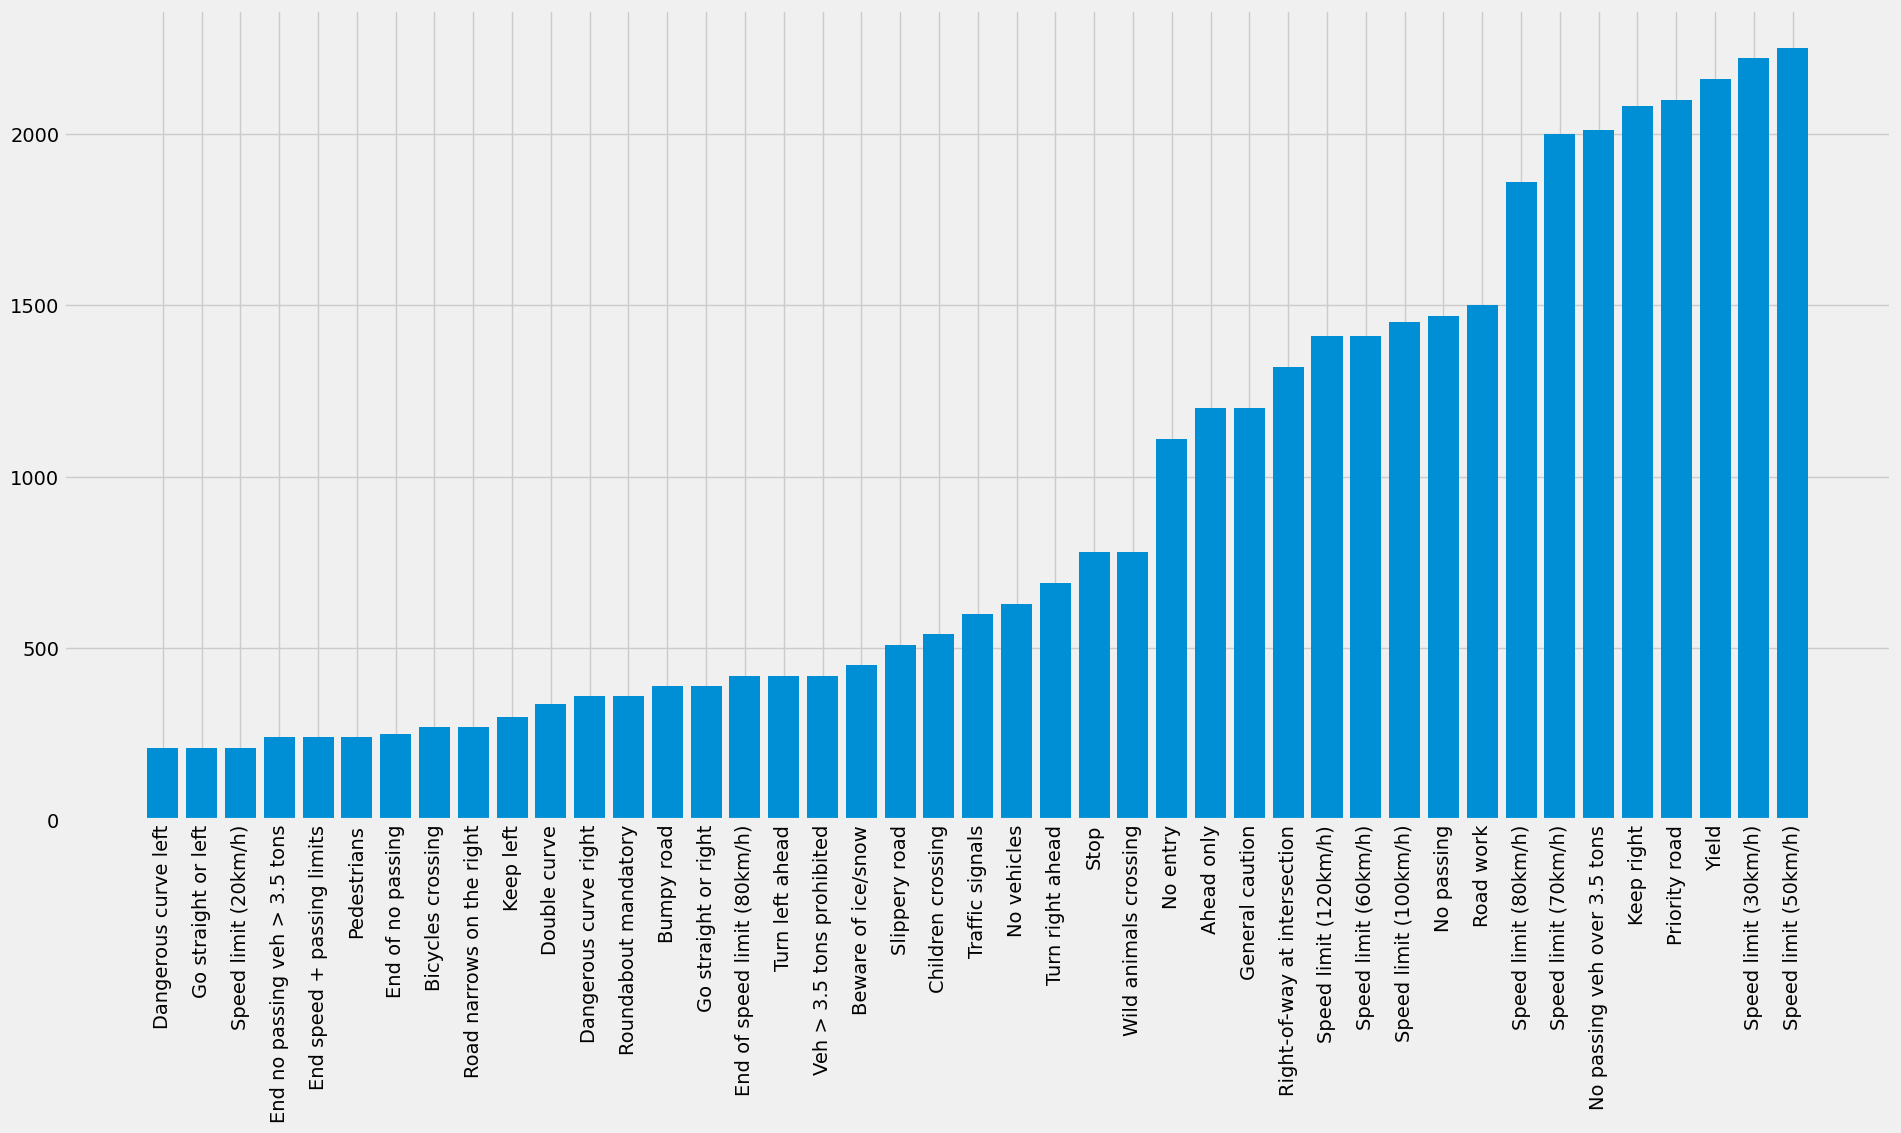

In [ ]:
folders = os.listdir(train_path)
train_number = []
class_num = []
for folder in folders:
  train_files = os.listdir(train_path + '/' + folder)
  train_number.append(len(train_files))
  class_num.append(classes [int(folder)])
# Sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted (zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in tuples]
# Plotting the number of images in each class
plt.figure(figsize=(21,10))
plt.bar(class_num, train_number)
plt.xticks (class_num, rotation='vertical')
plt.show()

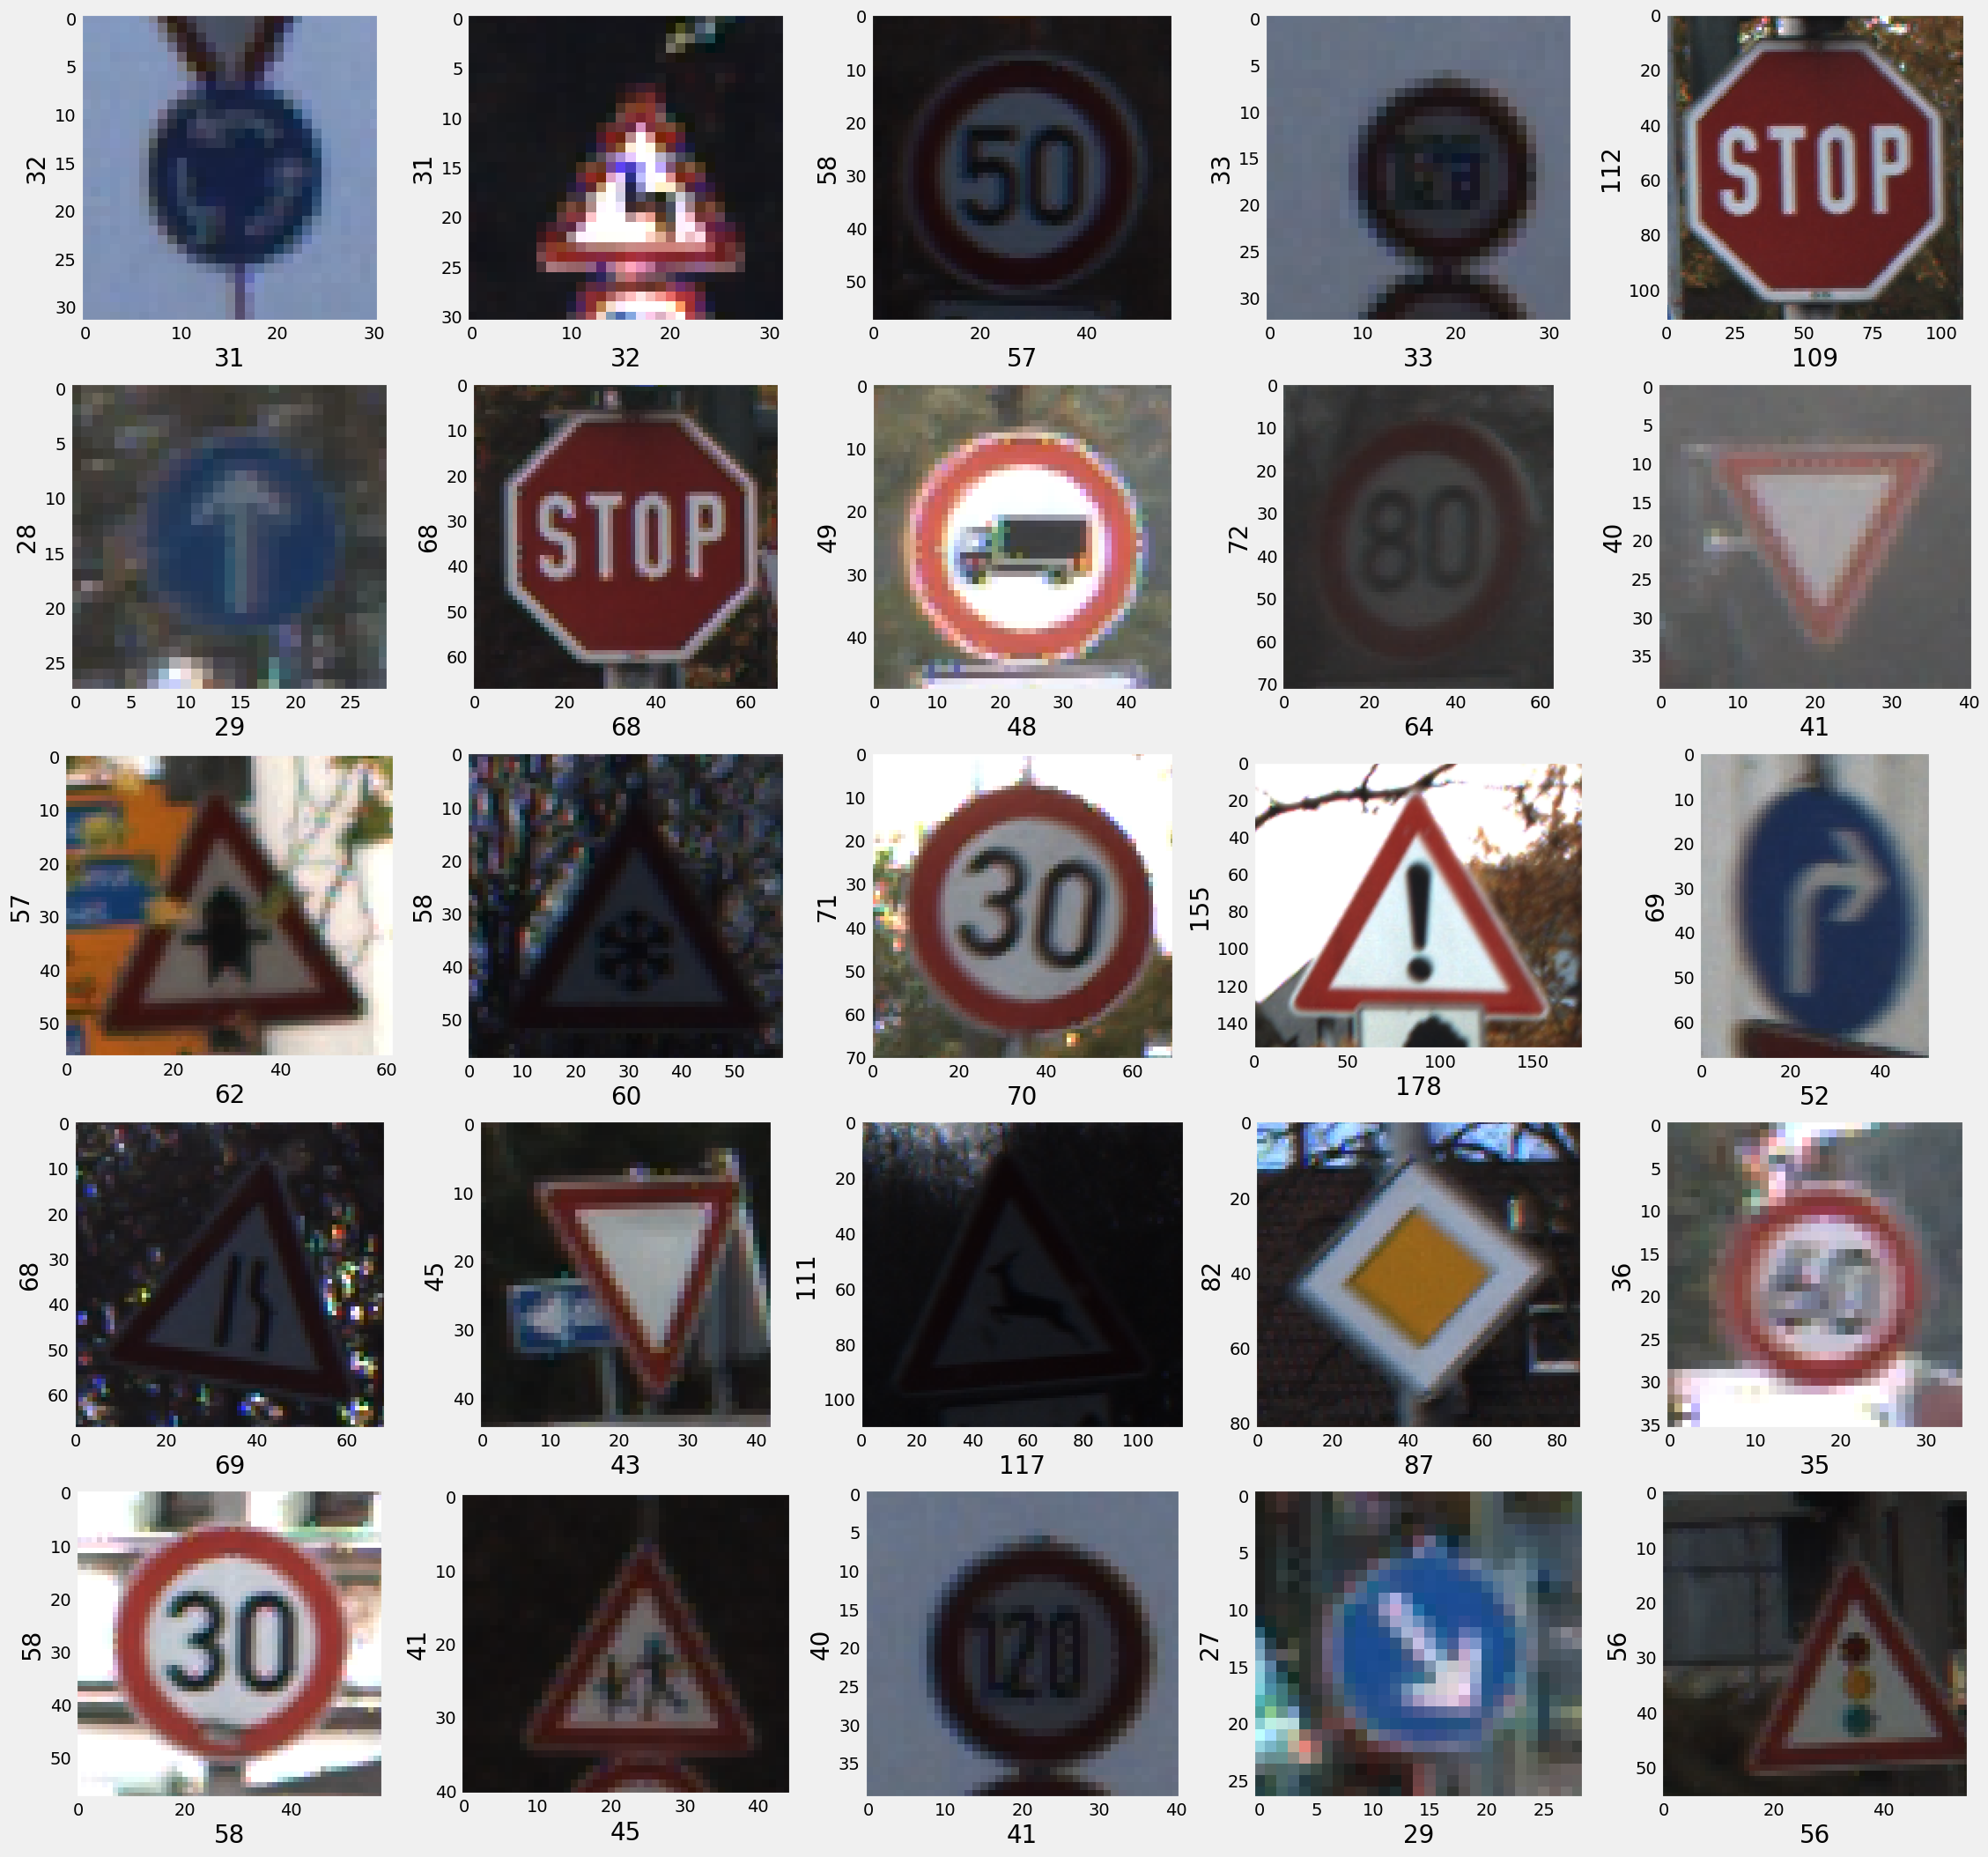

In [ ]:
#Visualizing 25 random images from test data
import random
from matplotlib.image import imread

test = pd.read_csv(data_dir + '/Test.csv')
imgs = test["Path"].values

plt.figure(figsize=(25,25))

for i in range(1,26):
  plt.subplot(5,5,i) # Changed the subplot index to i to display all 25 images
  random_img_path = data_dir + '/' + random.choice(imgs)
  rand_img=imread(random_img_path)
  plt.imshow(rand_img)
  plt.grid(visible=None) # Changed 'b' to 'visible'
  plt.xlabel(rand_img.shape[1], fontsize = 20)#width of image
  plt.ylabel(rand_img.shape[0], fontsize = 20)#height of image

In [ ]:
image_data = []
image_labels = []
for i in range(NUM_CATEGORIES):
    path = data_dir + '/Train/' + str(i)
    images = os.listdir(path)
    # Moved the inner loop inside the outer loop
    for img in images:
        try:
            image = cv2.imread(path + '/' + img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            image_data.append(np.array(resize_image))
            image_labels.append(i)
        except:
            print("Error in " + img)
# Convert to NumPy arrays outside the loop
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print(image_data.shape, image_labels.shape)

(39265, 30, 30, 3) (39265,)


In [ ]:
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data=image_data[shuffle_indexes]
image_labels = image_labels [shuffle_indexes]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.3, random_state=42, shuffle=True)
X_train=X_train/255
X_val=X_val/255
print("X_train.shape", X_train.shape)
print("X_valid.shape", X_val.shape)
print("y_train.shape", y_train.shape)
print("y_valid.shape", y_val.shape)

X_train.shape (27485, 30, 30, 3)
X_valid.shape (11780, 30, 30, 3)
y_train.shape (27485,)
y_valid.shape (11780,)


In [ ]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)
print(y_train.shape)
print(y_val.shape)

(27485, 43)
(11780, 43)


In [ ]:
model = keras.models.Sequential([
keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, channels)),
keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
keras.layers.MaxPool2D(pool_size=(2, 2)),
keras.layers.BatchNormalization(axis=-1),

keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
keras.layers.MaxPool2D(pool_size=(2, 2)),
keras.layers.BatchNormalization(axis=-1),
keras.layers.Flatten(),
keras.layers.Dense(512, activation='relu'),
keras.layers.BatchNormalization(),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(43, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
lr = 0.001
epochs = 30
# Use learning_rate instead of lr
opt = Adam(learning_rate=lr, decay=lr / (epochs * 0.5))
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
aug= ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")

history=model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=epochs, validation_data=(X_val, y_val))

NameError: name 'ImageDataGenerator' is not defined

In [ ]:
model.save("model.h5")

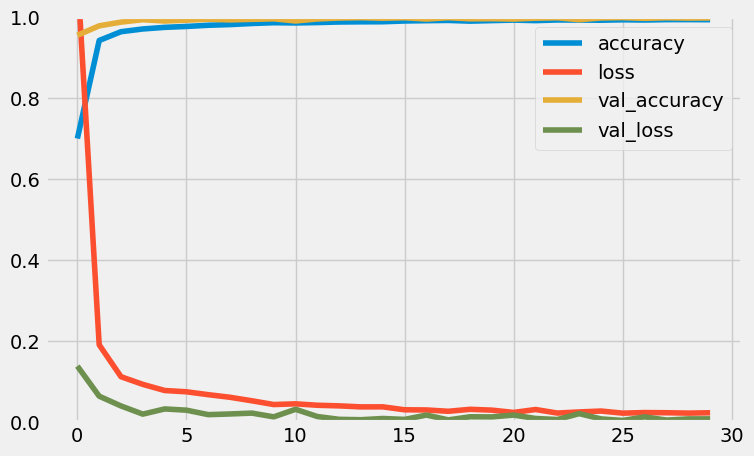

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
test = pd.read_csv(data_dir + '/Test.csv')
labels=test["ClassId"].values
imgs=test["Path"].values
data = []
for img in imgs:
  try:
    image = cv2.imread(data_dir + '/' + img)
    image_fromarray = Image.fromarray(image, 'RGB')
    resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
    data.append(np.array(resize_image))
  except:
    print("Error in "+ img)
X_test = np.array(data)
X_test = X_test/255
pred = model.predict_classes(X_test)
#Accuracy with the test data
print('Test Data accuracy:', accuracy_score(labels, pred)*100)

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(labels, pred))


NameError: name 'labels' is not defined

In [ ]:
plt.figure(figsize = (25,25))
start_index = 0
for i in range(25):
plt.subplot(5, 5, i + 1)
plt.grid(False)
plt.xticks([])
plt.yticks([])
prediction = pred [start_index + i]
actual = labels [start_index + i]
col = 'g'
if prediction != actual:
col = 'r'
plt.xlabel('Actual={} || Pred={}'.format(actual, prediction), color = col)
plt.imshow(X_test [start_index + i])
plt.show()

IndentationError: expected an indented block after 'for' statement on line 3 (<ipython-input-9-43a775539769>, line 4)